# Project 4 - Neural Radiance Field (NeRF)

In [44]:
# load libraries
import numpy as np
import skimage as sk
import skimage.io as skio
from skimage import img_as_ubyte
import matplotlib.pyplot as plt
from skimage.transform import resize

import cv2
import numpy as np
import glob # for loading multiple files
import viser # visualizations

# imports for part 1
import os
import math
import time
from functools import partial

from PIL import Image # for image loading

# pytorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

# 2.5 gif import
import imageio

## Part 0: Calibrating Your Camera and Capturing a 3D Scan

### Part 0.1: Calibrating Your Camera

In [ ]:
# calibration pipeline

# starter code from spec
# import cv2
# import numpy as np

# Create ArUco dictionary and detector parameters (4x4 tags)
aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
aruco_params = cv2.aruco.DetectorParameters()

# tag size
tag_size = 0.06 # meters, 0.02 = 2 cm
# 3d coordinates of aruco tag in world frame
obj_pts_single = np.array([
    [0, 0, 0],           # Top-left
    [tag_size, 0, 0],    # Top-right
    [tag_size, tag_size, 0],  # Bottom-right
    [0, tag_size, 0]     # Bottom-left
], dtype = np.float32)

obj_pts = [] # all 3D pts in world frame
img_pts = [] # all 2D pts in image frame

# images = glob.glob('calibration-images/*.JPG') # path to images
images = glob.glob('desk-calibration-images/*.jpg') # path to images, path file ending is case sensitive (e.g. jpg vs JPG are different)

for path in images:
    # load image
    im = cv2.imread(path)
    gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

    # Detect ArUco markers in an image
    # Returns: corners (list of numpy arrays), ids (numpy array)
    corners, ids, _ = cv2.aruco.detectMarkers(gray, aruco_dict, parameters=aruco_params) # modify to take in grayscale image

    # Check if any markers were detected
    if ids is None or len(ids) == 0:
        print(f"No ArUco detected in {path}, skipping.")
        continue
    # Process the detected corners
    # corners: list of length N (number of detected tags)
    #   - each element is a numpy array of shape (1, 4, 2) containing the 4 corner coordinates (x, y)
    # ids: numpy array of shape (N, 1) containing the tag IDs for each detected marker
    # Example: if 3 tags detected, corners will be a list of 3 arrays, ids will be shape (3, 1)
        # loop through all detected markers
    for c in corners:
        img_pts.append(c.reshape(4, 2)) # reshape from (1, 4, 2) to shape: (4,2)
        obj_pts.append(obj_pts_single) # append the same 3D points for each detected marker

# 5. calibrate camera
if len(obj_pts) >= 10:
    print(f"Using {len(obj_pts)} detected tags for calibration")
    img_shape = gray.shape[::-1] # (width, height)
    
    ret, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
        obj_pts,
        img_pts,
        img_shape,
        None, # initial camera matrix (estimated by OpenCV)
        None # initial distortion coefficients
    )

    print("Calibration successful!")
    print("Camera matrix (intrinsics):\n", camera_matrix) # camera_matrix = K from discussion
    print("Distortion coefficients:\n", dist_coeffs)
    print(f"Re-projection error: {ret:.4f} pixels")

else:
    print("No valid markers detected in any image. Calibration unsuccessful.")

Using 228 detected tags for calibration
Calibration successful!
Camera matrix (intrinsics):
 [[510.33297857   0.         218.38029735]
 [  0.         477.87526606 289.5891331 ]
 [  0.           0.           1.        ]]
Distortion coefficients:
 [[ 0.00687496  0.07407539  0.0462485  -0.02681677  0.14268749]]
Re-projection error: 0.2095 pixels


In [ ]:
# # test if programs work on spec's sample data
# # calibration pipeline

# # starter code from spec
# # import cv2
# # import numpy as np

# # Create ArUco dictionary and detector parameters (4x4 tags)
# aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
# aruco_params = cv2.aruco.DetectorParameters()

# # tag size
# tag_size = 0.06 # meters, 0.02 = 2 cm
# # 3d coordinates of aruco tag in world frame
# obj_pts_single = np.array([
#     [0, 0, 0],           # Top-left
#     [tag_size, 0, 0],    # Top-right
#     [tag_size, tag_size, 0],  # Bottom-right
#     [0, tag_size, 0]     # Bottom-left
# ], dtype = np.float32)

# obj_pts = [] # all 3D pts in world frame
# img_pts = [] # all 2D pts in image frame

# images = glob.glob('calibration-images/*.JPG') # path to images
# # images = glob.glob('desk-calibration-images/*.jpg') # path to images, path file ending is case sensitive (e.g. jpg vs JPG are different)

# for path in images:
#     # load image
#     im = cv2.imread(path)
#     gray = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

#     # Detect ArUco markers in an image
#     # Returns: corners (list of numpy arrays), ids (numpy array)
#     corners, ids, _ = cv2.aruco.detectMarkers(gray, aruco_dict, parameters=aruco_params) # modify to take in grayscale image

#     # Check if any markers were detected
#     if ids is None or len(ids) == 0:
#         print(f"No ArUco detected in {path}, skipping.")
#         continue
#     # Process the detected corners
#     # corners: list of length N (number of detected tags)
#     #   - each element is a numpy array of shape (1, 4, 2) containing the 4 corner coordinates (x, y)
#     # ids: numpy array of shape (N, 1) containing the tag IDs for each detected marker
#     # Example: if 3 tags detected, corners will be a list of 3 arrays, ids will be shape (3, 1)
#         # loop through all detected markers
#     for c in corners:
#         img_pts.append(c.reshape(4, 2)) # reshape from (1, 4, 2) to shape: (4,2)
#         obj_pts.append(obj_pts_single) # append the same 3D points for each detected marker

# # 5. calibrate camera
# if len(obj_pts) >= 10:
#     print(f"Using {len(obj_pts)} detected tags for calibration")
#     img_shape = gray.shape[::-1] # (width, height)
    
#     ret, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
#         obj_pts,
#         img_pts,
#         img_shape,
#         None, # initial camera matrix (estimated by OpenCV)
#         None # initial distortion coefficients
#     )

#     print("Calibration successful!")
#     print("Camera matrix (intrinsics):\n", camera_matrix) # camera_matrix = K from discussion
#     print("Distortion coefficients:\n", dist_coeffs)

# else:
#     print("No valid markers detected in any image. Calibration unsuccessful.")

### Part 0.3: Estimating Camera Pose

In [ ]:
# visualize
server = viser.ViserServer(share=True)

obj_images = glob.glob("octo-images-2/*.jpeg")
obj_images = sorted(obj_images)

# for part 0.4
undistorted_images = []
c2w_matrices = []

# update tag size bc i used a single 50mm tag instead of the pdf of 6 60mm tags
tag_size = 0.05 # meters

# redefine 3D corner coordinates of the tag in world coordinates
obj_pts_single = np.array([
    [0, 0, 0],           # Top-left
    [tag_size, 0, 0],    # Top-right
    [tag_size, tag_size, 0],  # Bottom-right
    [0, tag_size, 0]     # Bottom-left
], dtype = np.float32)


# for each image, detect the single aruco tag and use cv2.solvePnP() to estimate the camera pose
for i, path in enumerate(obj_images): # rn images = calibration images
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    corners, ids, _ = cv2.aruco.detectMarkers(gray, aruco_dict, parameters=aruco_params) # rerun marker detection

    if ids is None or len(ids) == 0:
        print(f"No ArUco detected in {path}, skipping.") # skip as before in part 0.1
        continue

    # use first marker
    img_pts_single = corners[0].reshape(4, 2).astype(np.float32) # reshape corners

    # outputs = solvePnP(inputs)
    success, rvec, tvec = cv2.solvePnP(obj_pts_single, img_pts_single, camera_matrix, dist_coeffs)
    if not success:
        print(f"PnP failed for {path}, skipping.") # check what's happening
        continue

    R, _ = cv2.Rodrigues(rvec) # convert to 3x3 rotation matrix
    t = tvec.reshape(3, 1)
    R_wc = R.T
    t_wc = -R.T @ t
    c2w = np.hstack([R_wc, t_wc]) # invert world-to-camera to get camera-to-world

    # UPDATE DON'T UNDISTORT
    # undistort the image
    # undistorted = cv2.undistort(img, camera_matrix, dist_coeffs)
    # convert BGR to RGB for NeRF
    # undistorted = undistorted[:, :, ::-1]
    undistorted = img[:, :, ::-1]
    # append/save
    undistorted_images.append(undistorted)
    c2w_full = np.eye(4)
    c2w_full[:3, :4] = c2w
    c2w_matrices.append(c2w_full)

    print(f"Added camera {i} to ViSer.")

    # convert BGR to RGB for viser
    img_rgb = img[:, :, ::-1]

    server.scene.add_camera_frustum(
        f"/cameras/{i}",
        fov=2 * np.arctan2(gray.shape[0] / 2, camera_matrix[0, 0]),
        aspect=gray.shape[1] / gray.shape[0],
        scale=0.02,
        wxyz=viser.transforms.SO3.from_matrix(c2w[:3, :3]).wxyz,
        position=c2w[:3, 3],
        image=img_rgb
    )


╭────── viser (listening *:8098) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8098   │
│   Websocket │ ws://localhost:8098     │
│             ╵                         │
╰───────────────────────────────────────╯

(viser) Share URL requested!

Python(71922) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(71923) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


(viser) Generated share URL (expires in 24 hours, max 16 clients): https://quad-candid.share.viser.studio

Added camera 0 to ViSer.
Added camera 1 to ViSer.
Added camera 2 to ViSer.
Added camera 3 to ViSer.
Added camera 4 to ViSer.
Added camera 5 to ViSer.
Added camera 6 to ViSer.
Added camera 7 to ViSer.
Added camera 8 to ViSer.
Added camera 9 to ViSer.
Added camera 10 to ViSer.
Added camera 11 to ViSer.
Added camera 12 to ViSer.
Added camera 13 to ViSer.
Added camera 14 to ViSer.
Added camera 15 to ViSer.
Added camera 16 to ViSer.
Added camera 17 to ViSer.
Added camera 18 to ViSer.
Added camera 19 to ViSer.
Added camera 20 to ViSer.
Added camera 21 to ViSer.
Added camera 22 to ViSer.
Added camera 23 to ViSer.
Added camera 24 to ViSer.
Added camera 25 to ViSer.
Added camera 26 to ViSer.
Added camera 27 to ViSer.
Added camera 28 to ViSer.
Added camera 29 to ViSer.
Added camera 30 to ViSer.
Added camera 31 to ViSer.
Added camera 32 to ViSer.
Added camera 33 to ViSer.
Added camera 34 to ViSer.
Added camera 35 to ViSer.
Added camera 36 to ViSer.
Added camera 37 to ViSer.
Added camera 38 to ViS

In [70]:
# visualize
server = viser.ViserServer(share=True)

obj_images = glob.glob("octo-images/*.jpg")
obj_images = sorted(obj_images)

# for part 0.4
undistorted_images = []
c2w_matrices = []

# update tag size bc i used a single 50mm tag instead of the pdf of 6 60mm tags
tag_size = 0.05 # meters

# redefine 3D corner coordinates of the tag in world coordinates
obj_pts_single = np.array([
    [0, 0, 0],           # Top-left
    [tag_size, 0, 0],    # Top-right
    [tag_size, tag_size, 0],  # Bottom-right
    [0, tag_size, 0]     # Bottom-left
], dtype = np.float32)

# for each image, detect the single aruco tag and use cv2.solvePnP() to estimate the camera pose
for i, path in enumerate(obj_images): # rn images = calibration images
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    corners, ids, _ = cv2.aruco.detectMarkers(gray, aruco_dict, parameters=aruco_params)
    if ids is None or len(ids) == 0:
        print(f"No ArUco detected in {path}, skipping.") # skip as before in part 0.1
        continue

    # use first marker
    img_pts_single = corners[0].reshape(4, 2).astype(np.float32) # reshape corners

    # outputs = solvePnP(inputs)
    success, rvec, tvec = cv2.solvePnP(obj_pts_single, img_pts_single, camera_matrix, dist_coeffs)
    if not success:
        print(f"PnP failed for {path}, skipping.") # check what's happening
        continue

    R, _ = cv2.Rodrigues(rvec) # convert to 3x3 rotation matrix
    t = tvec.reshape(3, 1)
    R_wc = R.T
    t_wc = -R.T @ t
    c2w = np.hstack([R_wc, t_wc]) # invert world-to-camera to get camera-to-world

    # undistort the image
    undistorted = cv2.undistort(img, camera_matrix, dist_coeffs)
    # convert BGR to RGB for NeRF
    undistorted = undistorted[:, :, ::-1]
    # append/save
    undistorted_images.append(undistorted)
    c2w_full = np.eye(4)
    c2w_full[:3, :4] = c2w
    c2w_matrices.append(c2w_full)

    # convert BGR to RGB for viser
    img_rgb = img[:, :, ::-1]

    server.scene.add_camera_frustum(
        f"/cameras/{i}",
        fov=2 * np.arctan2(gray.shape[0] / 2, camera_matrix[0, 0]),
        aspect=gray.shape[1] / gray.shape[0],
        scale=0.02,
        wxyz=viser.transforms.SO3.from_matrix(c2w[:3, :3]).wxyz,
        position=c2w[:3, 3],
        image=img_rgb
    )


╭────── viser (listening *:8095) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8095   │
│   Websocket │ ws://localhost:8095     │
│             ╵                         │
╰───────────────────────────────────────╯

(viser) Share URL requested!

Python(47923) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(47924) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


(viser) Generated share URL (expires in 24 hours, max 16 clients): https://risky-event.share.viser.studio

(viser) Connection opened (0, 1 total), 166 persistent messages

In [66]:
# # visualize
# server = viser.ViserServer(share=True)

# obj_images = glob.glob("lafufu-images/*.JPG")
# obj_images = sorted(obj_images)

# # for each image, detect the single aruco tag and use cv2.solvePnP() to estimate the camera pose
# for i, path in enumerate(obj_images): # rn images = calibration images
#     img = cv2.imread(path)
#     gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#     corners, ids, _ = cv2.aruco.detectMarkers(gray, aruco_dict, parameters=aruco_params)
#     if ids is None or len(ids) == 0:
#         print(f"No ArUco detected in {path}, skipping.") # skip as before in part 0.1
#         continue

#     # use first marker
#     img_pts_single = corners[0].reshape(4, 2).astype(np.float32) # reshape corners

#     # outputs = solvePnP(inputs)
#     success, rvec, tvec = cv2.solvePnP(obj_pts_single, img_pts_single, camera_matrix, dist_coeffs)
#     if not success:
#         print(f"PnP failed for {path}, skipping.") # check what's happening
#         continue

#     R, _ = cv2.Rodrigues(rvec) # convert to 3x3 rotation matrix
#     t = tvec.reshape(3, 1)
#     R_wc = R.T
#     t_wc = -R.T @ t
#     c2w = np.hstack([R_wc, t_wc]) # invert world-to-camera to get camera-to-world

#     # convert BGR to RGB for viser
#     img_rgb = img[:, :, ::-1]

#     server.scene.add_camera_frustum(
#         f"/cameras/{i}",
#         fov=2 * np.arctan2(gray.shape[0] / 2, camera_matrix[0, 0]),
#         aspect=gray.shape[1] / gray.shape[0],
#         scale=0.02,
#         wxyz=viser.transforms.SO3.from_matrix(c2w[:3, :3]).wxyz,
#         position=c2w[:3, 3],
#         image=img_rgb
#     )


### Part 0.4: Undistorting images and creating a dataset

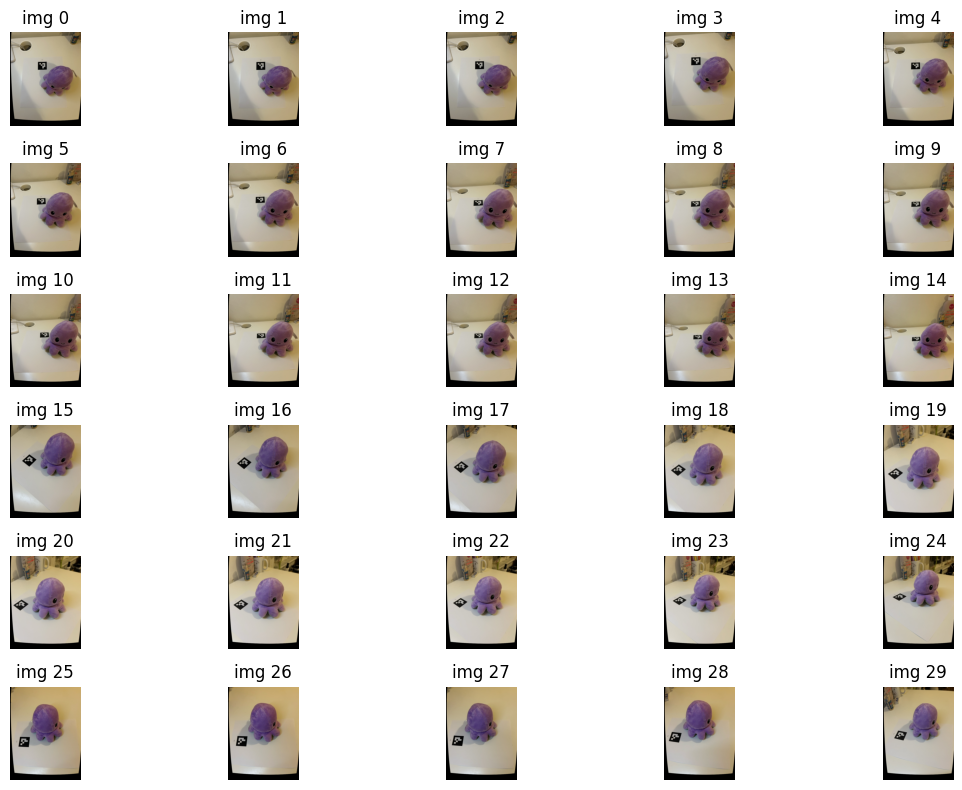

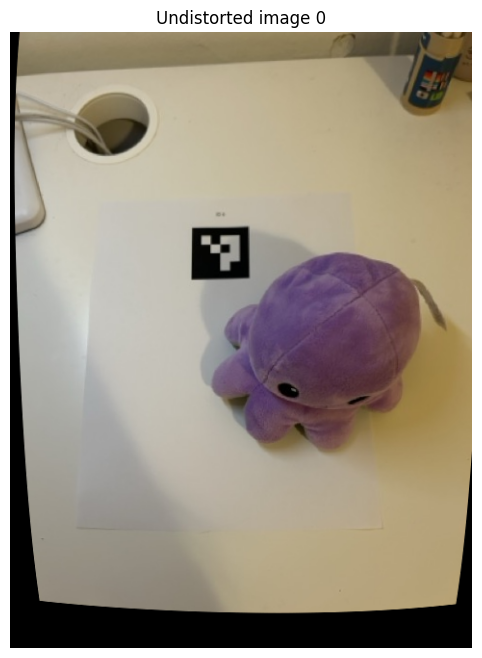

(viser) Connection closed (0, 0 total)

In [95]:
# after for loop to solve PnP + viser
undistorted_images = np.array(undistorted_images) # (N, H, W, 3)
c2w_matrices = np.array(c2w_matrices) # (N, 4, 4)


# visualization helper
def show_image_grid(imgs, n_cols=5, figsize=(15,8), save_path=None):
    import math
    n = len(imgs)
    if n == 0:
        print("No images to show.")
        return
    n_cols = min(n_cols, n)
    n_rows = math.ceil(n / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)
    for i, ax in enumerate(axes):
        if i < n:
            im = imgs[i]
            # ensure uint8 RGB for imshow
            if im.dtype != np.uint8:
                im = (np.clip(im, 0.0, 1.0) * 255).astype(np.uint8)
            ax.imshow(im)
            ax.set_title(f"img {i}")
            ax.axis("off")
        else:
            ax.axis("off")
    plt.tight_layout()
    plt.show()

# show first 20 undistorted images in a grid
show_image_grid(undistorted_images[:30], n_cols=5, figsize=(12,8))

# show a single image (index 0) larger
plt.figure(figsize=(8,8))
plt.imshow(undistorted_images[0])
plt.axis("off")
plt.title("Undistorted image 0")
plt.show()

# --------------------------------

# train/test split
# train/val/test = 80/10/10
N = len(undistorted_images)
idx_train = int(0.8 * N)
idx_val = int(0.9 * N)

images_train = undistorted_images[:idx_train]
c2ws_train = c2w_matrices[:idx_train]

images_val = undistorted_images[idx_train:idx_val]
c2ws_val = c2w_matrices[idx_train:idx_val]

c2ws_test = c2w_matrices[idx_val:]

# use average of fx and fy to extract focal length
focal = float((camera_matrix[0, 0] + camera_matrix[1, 1]) / 2)

# from spec to save dataset
# Package your data (keep images in 0-255 range, they'll be normalized when loaded)
# np.savez(
#     'octo_data.npz',
#     images_train=images_train,    # (N_train, H, W, 3)
#     c2ws_train=c2ws_train,        # (N_train, 4, 4)
#     images_val=images_val,        # (N_val, H, W, 3)
#     c2ws_val=c2ws_val,            # (N_val, 4, 4)
#     c2ws_test=c2ws_test,          # (N_test, 4, 4)
#     focal=focal                   # float
# )

# print("Saved dataset to octo_data.npz")

In [ ]:
# # after for loop to solve PnP + viser
# undistorted_images = np.array(undistorted_images) # (N, H, W, 3)
# c2w_matrices = np.array(c2w_matrices) # (N, 4, 4)

# # train/test split
# # train/val/test = 80/10/10
# N = len(undistorted_images)
# idx_train = int(0.8 * N)
# idx_val = int(0.9 * N)

# images_train = undistorted_images[:idx_train]
# c2ws_train = c2w_matrices[:idx_train]

# images_val = undistorted_images[idx_train:idx_val]
# c2ws_val = c2w_matrices[idx_train:idx_val]

# c2ws_test = c2w_matrices[idx_val:]

# # use average of fx and fy to extract focal length
# focal = float((camera_matrix[0, 0] + camera_matrix[1, 1]) / 2)

# # from spec to save dataset
# # Package your data (keep images in 0-255 range, they'll be normalized when loaded)
# np.savez(
#     'my_data.npz',
#     images_train=images_train,    # (N_train, H, W, 3)
#     c2ws_train=c2ws_train,        # (N_train, 4, 4)
#     images_val=images_val,        # (N_val, H, W, 3)
#     c2ws_val=c2ws_val,            # (N_val, 4, 4)
#     c2ws_test=c2ws_test,          # (N_test, 4, 4)
#     focal=focal                   # float
# )

# print("Saved dataset to my_data.npz")

## Part 1: Fit a Neural Field to a 2D Image

In [101]:
# for part 1
image_path = "part1-images/fox.jpg" # path to our image
device = torch.device("mps" if torch.mps.is_available() else "cpu") # using mps for m1 mac
out_dir = "part1-results-home" # new folder to save results
os.makedirs(out_dir, exist_ok = True)

# training hyperparameters
num_iters = 2000 # 1000-3000 iterations recommended
batch_size = 10000 # sample pixels per iteration
lr = 1e-2 # use adam optimizer, PSNR instead of MSE
log_every = 200 # save recon every `log_every` iterations

# hyperparameters
default_width = 256
default_layers = 3 # number of hidden linear layers (as in figure)
default_pe_L = 10  # max frequency L (PE will use 2^0..2^(L-1))

# helper functions
# convert image to RGB and return as a np array
def load_image_np(path):
    im = Image.open(path).convert("RGB")
    arr = np.array(im).astype(np.uint8)
    return arr

def img_to_coords_and_colors(img_np):
    H, W = img_np.shape[:2]
    # create pixel coordinates (x,y) convention: center or top-left? Here we normalize by width/height
    xs = np.arange(W)
    ys = np.arange(H)
    xv, yv = np.meshgrid(xs, ys)
    coords = np.stack([xv, yv], axis=-1).reshape(-1, 2) # (H*W, 2)
    colors = img_np.reshape(-1, 3) / 255.0 # normalize to [0,1]
    return coords.astype(np.float32), colors.astype(np.float32), H, W

def compute_psnr(mse):
    # image normalized [0,1]
    if mse <= 0:
        return float("inf")
    return 10.0 * math.log10(1.0 / mse) # PSNR formula from spec

# positional encoding
class PositionalEncoding2D(nn.Module):
    def __init__(self, L):
        """
        L: number of frequencies. Produces features:
           [x, y, sin(2^0 pi x), cos(2^0 pi x), ..., sin(2^(L-1) pi x), cos(2^(L-1) pi x),
                  sin(2^0 pi y), cos(2^0 pi y), ..., sin(2^(L-1) pi y), cos(2^(L-1) pi y)]
           The original coordinate (x,y) is kept as well.
        """
        super().__init__()
        self.L = L
        # precompute scales: 2^k * pi
        self.register_buffer("scales", torch.tensor([ (2**k) * math.pi for k in range(L) ], dtype=torch.float32)) # store frequency bands

    def forward(self, coords_norm): # expand dimensionality by applying sinusoidal functions
        # coords_norm: (N, 2) where coords are normalized to [0,1]
        x = coords_norm[..., 0:1]  # (N,1)
        y = coords_norm[..., 1:2]
        out = [x, y]
        for s in self.scales: # apply sinusoidal functions to input coordinates
            out.append(torch.sin(x * s))
            out.append(torch.cos(x * s))
        for s in self.scales:
            out.append(torch.sin(y * s))
            out.append(torch.cos(y * s))
        return torch.cat(out, dim=-1)  # (N, 2 + 4*L)

# implement MLP network
class SimpleMLP(nn.Module):
    def __init__(self, in_dim, width=256, hidden_layers=3): # hidden layer width, 3 hidden layers
        super().__init__()
        layers = []
        last = in_dim
        for i in range(hidden_layers):
            layers.append(nn.Linear(last, width))
            layers.append(nn.ReLU(inplace=True))
            last = width
        # final linear to 3 channels
        layers.append(nn.Linear(last, 3))
        layers.append(nn.Sigmoid()) # sigmoid activation, outputs in [0,1]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# dataloader
class RandomPixelDataset(Dataset):
    def __init__(self, coords, colors):
        """
        coords: (Npix, 2) in pixel coords (0..W-1, 0..H-1)
        colors: (Npix, 3) normalized [0,1]
        """
        self.coords = coords
        self.colors = colors
        self.N = coords.shape[0]

    def __len__(self):
        return self.N

    def __getitem__(self, idx):
        return self.coords[idx], self.colors[idx]

# run function for just a single training run
def train_single_run(image_path,
                     pe_L=10,
                     width=256,
                     hidden_layers=3,
                     num_iters=2000,
                     batch_size=10000, # staff on Ed recommends a batch size of 10k pixels
                     lr=1e-2, # Ed-recommended learning rate
                     log_every=200,
                     out_dir="part1-results"):
    np_img = load_image_np(image_path)
    coords, colors, H, W = img_to_coords_and_colors(np_img)
    Npix = coords.shape[0]

    # normalize coords to [0,1]
    coords_norm = coords.copy()
    coords_norm[:, 0] = coords_norm[:, 0] / (W - 1) # x / (W-1)
    coords_norm[:, 1] = coords_norm[:, 1] / (H - 1) # y / (H-1)

    device_local = device

    # prepare PE and model
    pe = PositionalEncoding2D(pe_L).to(device_local)
    # input dimension after PE == 2 + 4*L
    in_dim = 2 + 4 * pe_L
    model = SimpleMLP(in_dim, width=width, hidden_layers=hidden_layers).to(device_local)

    # optimizer + loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) # use adam optimizer
    criterion = nn.MSELoss()

    # prepare dataset arrays as tensors (we will sample indices each iteration)
    coords_norm_t = torch.from_numpy(coords_norm).to(device_local)   # (Npix,2)
    colors_t = torch.from_numpy(colors).to(device_local)             # (Npix,3)

    losses = []
    psnrs = []
    start_time = time.time()

    # for monitoring, create a fixed validation set (1000 random pixels)
    rng = np.random.RandomState(123)
    val_idx = rng.choice(Npix, size=min(1000, Npix), replace=False)
    val_coords = coords_norm_t[val_idx]
    val_colors = colors_t[val_idx]

    # main training loop
    for it in range(1, num_iters + 1):
        # sample pixel indices
        idx = np.random.randint(0, Npix, size=batch_size)
        batch_coords = coords_norm_t[idx]  # (batch,2)
        batch_colors = colors_t[idx]       # (batch,3)

        # forward
        pe_feats = pe(batch_coords)        # (batch, in_dim)
        preds = model(pe_feats)            # (batch,3)

        loss = criterion(preds, batch_colors)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        # validation PSNR every iteration or per log
        if it % max(1, log_every // 5) == 0:
            with torch.no_grad():
                val_preds = model(pe(pe_coords := val_coords))
                val_mse = F.mse_loss(val_preds, val_colors).item()
                val_psnr = compute_psnr(val_mse)
                psnrs.append(val_psnr)

        # save reconstructions periodically
        if it % log_every == 0 or it == 1 or it == num_iters:
            with torch.no_grad():
                # reconstruct full image (may be slow for large images)
                all_pe = pe(coords_norm_t)  # (Npix, in_dim)
                all_preds = model(all_pe).cpu().numpy()  # (Npix,3)
                recon = (all_preds.reshape(H, W, 3) * 255.0).clip(0, 255).astype(np.uint8)
                out_img_path = os.path.join(out_dir, f"recon_pe{pe_L}_w{width}_iter{it:04d}.png")
                Image.fromarray(recon).save(out_img_path)
                msg = f"iter {it}/{num_iters}: loss={loss.item():.6f}"
                if 'val_psnr' in locals():
                    msg += f", val_psnr={val_psnr:.2f} dB"
                msg += f" -> saved {out_img_path}"
                print(msg)


    elapsed = time.time() - start_time
    print(f"Training finished in {elapsed:.1f}s")

    # final full recon
    with torch.no_grad():
        all_pe = pe(coords_norm_t)
        all_preds = model(all_pe).cpu().numpy()
        recon = (all_preds.reshape(H, W, 3) * 255.0).clip(0, 255).astype(np.uint8)
        final_path = os.path.join(out_dir, f"final_recon_pe{pe_L}_w{width}.png")
        Image.fromarray(recon).save(final_path)

    # return logs and final image path
    return {
        "losses": losses,
        "psnrs": psnrs,
        "final_image_path": final_path,
        "recon_paths": sorted([p for p in os.listdir(out_dir) if p.startswith(f"recon_pe{pe_L}_w{width}")])
    }

# 2x2 grid and plot PSNR curve + 2x2 images helper function
def run_grid_and_plot(image_path,
                      pe_list=[4, 10],
                      width_list=[32, 256],
                      num_iters=2000,
                      batch_size=10000,
                      lr=1e-2,
                      log_every=500):
    results = {}
    for pe_L in pe_list:
        for width in width_list:
            print(f"\n--- RUN: PE L={pe_L}, width={width} ---")
            res = train_single_run( # calls train_single_run 4 times using different hyperparameters
                image_path,
                pe_L=pe_L,
                width=width,
                hidden_layers=3,
                num_iters=num_iters,
                batch_size=batch_size,
                lr=lr,
                log_every=log_every,
                out_dir=out_dir
            )
            results[(pe_L, width)] = res

    # Plot last reconstructions in a 2x2 grid
    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    axs = axs.flatten()
    keys = list(results.keys())
    for i, k in enumerate(keys[:4]):
        path = results[k]["final_image_path"]
        img = Image.open(path)
        axs[i].imshow(img)
        axs[i].set_title(f"PE L={k[0]}, width={k[1]}")
        axs[i].axis("off")
    plt.suptitle("Final reconstructions (2x2 grid)")
    plt.savefig(os.path.join(out_dir, "final_reconstructions_grid.png"))
    plt.show()

    # Plot PSNR curve for first experiment
    first_key = keys[0]
    psnrs = results[first_key]["psnrs"]
    plt.figure(figsize=(6,4))
    iterations = np.linspace(0, num_iters, len(psnrs))
    plt.plot(iterations, psnrs)
    plt.xlabel("Iteration")
    plt.ylabel("PSNR (dB)")
    plt.title(f"PSNR curve for PE L={first_key[0]}, width={first_key[1]}")
    plt.grid(True)
    plt.savefig(os.path.join(out_dir, "psnr_curve.png"))
    plt.show()

    return results

# test run
if __name__ == "__main__":
    # test run to check functionality
    # res = train_single_run(image_path, pe_L=10, width=256, hidden_layers=3, num_iters=num_iters, batch_size=batch_size, lr=lr, log_every=log_every, out_dir=out_dir)

    # run the 2x2 grid (train 4 models sequentially)
    grid_res = run_grid_and_plot(image_path, pe_list=[4,10], width_list=[32,256], num_iters=num_iters, batch_size=batch_size, lr=lr, log_every=log_every)

    print("Module loaded. To run training, call train_single_run(...) or run_grid_and_plot(...).")



--- RUN: PE L=4, width=32 ---
iter 1/2000: loss=0.098112 -> saved part1-results-home/recon_pe4_w32_iter0001.png


KeyboardInterrupt: 


--- RUN: PE L=4, width=32 ---
iter 1/2000: loss=0.057455 -> saved part1-results-home/recon_pe4_w32_iter0001.png
iter 200/2000: loss=0.015194, val_psnr=18.32 dB -> saved part1-results-home/recon_pe4_w32_iter0200.png
iter 400/2000: loss=0.013880, val_psnr=18.72 dB -> saved part1-results-home/recon_pe4_w32_iter0400.png
iter 600/2000: loss=0.012004, val_psnr=18.92 dB -> saved part1-results-home/recon_pe4_w32_iter0600.png
iter 800/2000: loss=0.011381, val_psnr=19.39 dB -> saved part1-results-home/recon_pe4_w32_iter0800.png
iter 1000/2000: loss=0.011235, val_psnr=19.40 dB -> saved part1-results-home/recon_pe4_w32_iter1000.png
iter 1200/2000: loss=0.010974, val_psnr=19.43 dB -> saved part1-results-home/recon_pe4_w32_iter1200.png
iter 1400/2000: loss=0.010543, val_psnr=19.51 dB -> saved part1-results-home/recon_pe4_w32_iter1400.png
iter 1600/2000: loss=0.010472, val_psnr=19.55 dB -> saved part1-results-home/recon_pe4_w32_iter1600.png
iter 1800/2000: loss=0.010188, val_psnr=19.59 dB -> saved p

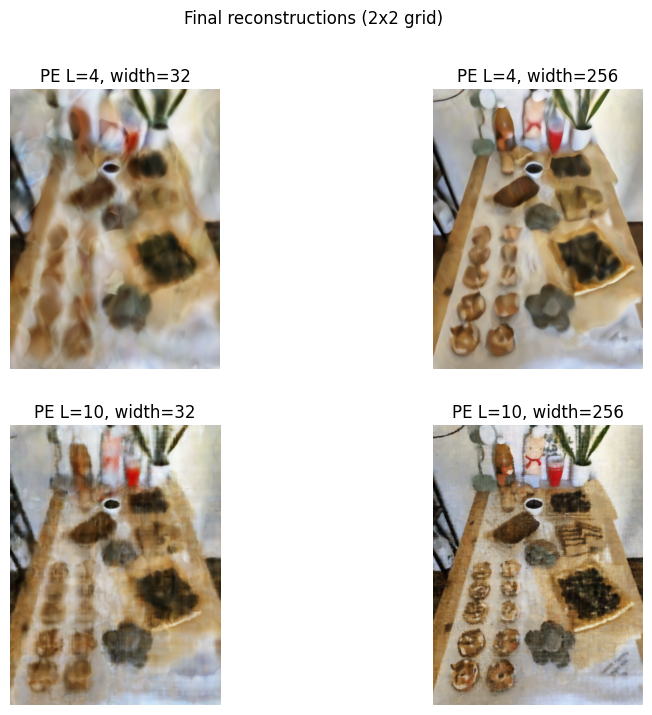

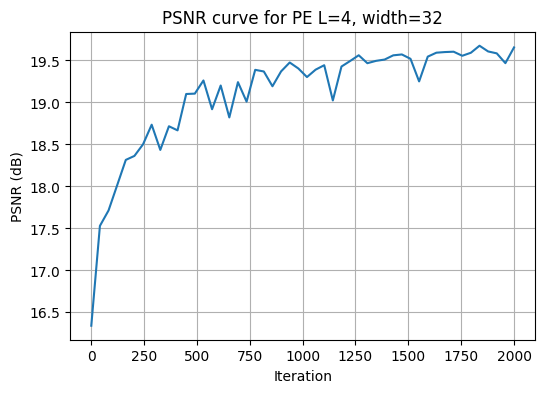

Module loaded. To run training, call train_single_run(...) or run_grid_and_plot(...).


In [102]:
# testing on an image of my choice
image_path = "part1-images/home_cafe.jpg" # path to new image

if __name__ == "__main__":
    # test run to check functionality
    # res = train_single_run(image_path, pe_L=10, width=256, hidden_layers=3, num_iters=num_iters, batch_size=batch_size, lr=lr, log_every=log_every, out_dir=out_dir)

    # run the 2x2 grid (train 4 models sequentially)
    grid_res = run_grid_and_plot(image_path, pe_list=[4,10], width_list=[32,256], num_iters=num_iters, batch_size=batch_size, lr=lr, log_every=log_every)

    print("Module loaded. To run training, call train_single_run(...) or run_grid_and_plot(...).")


## Part 2: Fit a Neural Radiance Field from Multi-view Images

In [103]:
device = torch.device("mps" if torch.mps.is_available() else "cpu") # using mps for m1 mac

In [104]:
# 2d to neural radience field
# use inverse rendering from multi-view calibrated images

# sepc code to parse data (from lego dataset)
data = np.load(f"lego_200x200.npz")

# Training images: [100, 200, 200, 3]
images_train = data["images_train"] / 255.0

# Cameras for the training images 
# (camera-to-world transformation matrix): [100, 4, 4]
c2ws_train = data["c2ws_train"]

# Validation images: 
images_val = data["images_val"] / 255.0

# Cameras for the validation images: [10, 4, 4]
# (camera-to-world transformation matrix): [10, 200, 200, 3]
c2ws_val = data["c2ws_val"]

# Test cameras for novel-view video rendering: 
# (camera-to-world transformation matrix): [60, 4, 4]
c2ws_test = data["c2ws_test"]

# Camera focal length
focal = data["focal"]  # float

### Part 2.1: Create Rays from Cameras

In [105]:
# camera to world space function
def transform(c2w, x_c):
    """
    trasnform points from camera coordinates to world coordinates
    
    inputs:
        c2w (torch.Tensor): camera-to-world matrix, shape (B, 4, 4) or (4, 4)
        x_c (torch.Tensor): pts in camera coordinates, shape (B, N, 3) or (N, 3)
        
    output:
        torch.Tensor: pts in world coordinates, shape (B, N, 3) or (N, 3)
    """
    # 1. add homogeneous coordinate (w=1)
    ones = torch.ones_like(x_c[..., :1]) 
    x_c_hom = torch.cat([x_c, ones], dim=-1)
    
    # 2. apply transformation
    # want to multiply (..., 4, 4) @ (..., 4, N)
    # permute x_c_hom to (..., 4, N)
    x_c_hom_perm = x_c_hom.permute(0, 2, 1)
    
    # perform matrix multiplication: (..., 4, 4) @ (..., 4, N) -> (..., 4, N)
    if c2w.dim() == 2:
        c2w = c2w.unsqueeze(0) # (1, 4, 4)
    if x_c_hom_perm.dim() == 2:
        x_c_hom_perm = x_c_hom_perm.unsqueeze(0) # (1, 4, N)
        
    x_w_hom_perm = c2w @ x_c_hom_perm
    
    # 3. permute back and de-homogenize
    x_w_hom = x_w_hom_perm.permute(0, 2, 1)  # Shape: (..., N, 4)
    
    # divide by the w-coordinate
    x_w = x_w_hom[..., :3] / x_w_hom[..., 3:4]
    
    return x_w.squeeze() # squeeze to remove batch dim if it was added

# pixel coordinate back to camera coordinate system
def pixel_to_camera(K, uv, s = 1.0):
    """
    2D pixel coordinates to 3D camera coordinates
    
    inputs:
        K (torch.Tensor): intrinsic matrix, shape (B, 3, 3) or (3, 3)
        uv (torch.Tensor): pixel coordinates, shape (B, N, 2) or (N, 2)
        s (float or torch.Tensor): depth(s), broadcastable to (B, N, 1)
        
    output:
        torch.Tensor: 3D pts in camera coordinates, shape (B, N, 3) or (N, 3)
    """
    # extract intrinsics (making sure they can be broadcast)
    fx = K[..., 0, 0].unsqueeze(-1)  
    fy = K[..., 1, 1].unsqueeze(-1)
    ox = K[..., 0, 2].unsqueeze(-1)
    oy = K[..., 1, 2].unsqueeze(-1)
    
    u = uv[..., 0:1]
    v = uv[..., 1:2]
    
    # inverse projection formulas
    x_c = s * (u - ox) / fx
    y_c = s * (v - oy) / fy
    
    # z_c = s from spec
    # a tensor of s with the same shape as x_c
    if isinstance(s, float):
        z_c = torch.full_like(x_c, s)
    else:
        z_c = s * torch.ones_like(x_c)

    return torch.cat([x_c, y_c, z_c], dim=-1)

# convert pixel coordinate to a ray with origin and normalized direction
def pixel_to_ray(K, c2w, uv):
    """
    calculate ray origins and directions for pixels
    
    inputs:
        K (torch.Tensor): intirnsic matrix, shape (3, 3)
        c2w (torch.Tensor): camera-to-world matrix, shape (4, 4)
        uv (torch.Tensor): pixel coordinates, shape (N, 2)
        
    output:
        (torch.Tensor, torch.Tensor): 
            - r_o: rya origins, shape (N, 3)
            - r_d: ray directions, shape (N, 3)
    """
    N = uv.shape[0]
    
    # 1. get ray origin (r_o)
    # camera's position = translation t part of c2w 
    r_o_world = c2w[:3, 3]
    r_o = r_o_world.unsqueeze(0).expand(N, -1)
    
    # 2. account for pixel center
    uv_centered = uv + 0.5 # offset by 0.5 to get the pixel center
    
    # 3. find 3D point in camera space (at s = 1)
    # add a batch dimension (1) for pixel_to_camera
    p_cam = pixel_to_camera(K.unsqueeze(0), uv_centered.unsqueeze(0), s=1.0) # (1, N, 3)
    
    # 4. transform pt from camera space to world space
    # add a batch dimension (1) for transform()
    p_world = transform(c2w.unsqueeze(0), p_cam) # (1, N, 3)
    p_world = p_world.squeeze(0) # (N, 3)
    
    # 5. compute ray direction (r_d)
    # r_d = p_world - r_o 
    r_d_unnormalized = p_world - r_o
    r_d = F.normalize(r_d_unnormalized, dim=-1)  # Shape: (N, 3)
    
    return r_o, r_d

In [106]:
def pixel_to_ray_batch(K, c2ws, uv):
    """
    BATCHED version - processes multiple cameras at once
    (Optimized for MPS by replacing einsum with bmm)
    
    inputs:
        K: (3, 3) intrinsic matrix
        c2ws: (N, 4, 4) camera-to-world matrices
        uv: (N, 2) pixel coordinates
        
    output:
        r_o: (N, 3) ray origins
        r_d: (N, 3) ray directions
    """
    N = uv.shape[0]
    
    # 1. Extract camera positions (ray origins)
    r_o = c2ws[:, :3, 3]  # (N, 3)
    
    # 2. Unproject pixels to camera space
    fx, fy = K[0, 0], K[1, 1]
    cx, cy = K[0, 2], K[1, 2]
    
    u, v = uv[:, 0], uv[:, 1]
    
    # Camera-space direction (at depth z=1)
    x_c = (u - cx) / fx
    y_c = (v - cy) / fy
    z_c = torch.ones_like(x_c)
    
    dirs_c = torch.stack([x_c, y_c, z_c], dim=-1)  # (N, 3)
    
    # 3. Transform to world space (using bmm)
    R = c2ws[:, :3, :3]  # (N, 3, 3)
    
    # --- THIS IS THE FIX ---
    # Old (slow) line:
    # dirs_w = torch.einsum('nij,nj->ni', R, dirs_c)
    
    # New (fast) lines:
    # Reshape for bmm: (N, 3) -> (N, 3, 1)
    dirs_c_batch = dirs_c.unsqueeze(-1)
    # Batched matrix multiply: (N, 3, 3) @ (N, 3, 1) -> (N, 3, 1)
    dirs_w_batch = torch.bmm(R, dirs_c_batch)
    # Reshape back: (N, 3, 1) -> (N, 3)
    dirs_w = dirs_w_batch.squeeze(-1)
    # -----------------------
    
    # 4. Normalize
    r_d = F.normalize(dirs_w, dim=-1)
    
    return r_o, r_d

### Part 2.2: Sampling

In [107]:
def sample_rays(images, c2ws, K, n_rays_to_sample):
    """
    sample rays from images
    
    inputs:
        images (torch.Tensor): training images, shape (N_img, H, W, 3)
        c2ws (torch.Tensor): camera-to-world matrices, shape (N_img, 4, 4)
        K (torch.Tensor): camera intrinsic matrix, shape (3, 3)
        n_rays_to_sample (int): The number of rays to sample (batch size)
        
    output:
        (torch.Tensor, torch.Tensor, torch.Tensor):
            - r_o: ray origins, shape (n_rays_to_sample, 3)
            - r_d: ray directions, shape (n_rays_to_sample, 3)
            - gt_colors: ground-truth pixel colors, shape (n_rays_to_sample, 3)
    """
    N_img, H, W = images.shape[:3]
    
    # 1. get random image indices
    # pick n_rays_to_sample (input parameter) random images (with replacement)
    img_indices = torch.randint(0, N_img, (n_rays_to_sample,), device=images.device)
    
    # 2. get random pixel coordinates (u, v)
    u_coords = torch.randint(0, W, (n_rays_to_sample,), device=images.device)
    v_coords = torch.randint(0, H, (n_rays_to_sample,), device=images.device)
    
    # 3. corresponding camera-to-world matrices
    batch_c2ws = c2ws[img_indices]
    
    # 4. corresponding ground-truth colors
    # use (v, u) indices to index into (H, W)
    gt_colors = images[img_indices, v_coords, u_coords]
    
    # 5. create (u, v) pixel coordinate tensor
    uv_coords = torch.stack([u_coords, v_coords], dim=-1)
    
    # 6. conver pixels to rays
    all_r_o = []
    all_r_d = []
    
    # might need to batch to make faster?
    for i in range(n_rays_to_sample):
        # r_o, r_d = pixel_to_ray(K, batch_c2ws[i], uv_coords[i:i+1]) # a (1, 2) tensor
        r_o, r_d = pixel_to_ray_batch(K, batch_c2ws[i], uv_coords[i:i+1]) # a (1, 2) tensor
        
        all_r_o.append(r_o)
        all_r_d.append(r_d)
        
    r_o = torch.cat(all_r_o, dim=0) # (n_rays_to_sample, 3)
    r_d = torch.cat(all_r_d, dim=0) # (n_rays_to_sample, 3)

    return r_o, r_d, gt_colors

def sample_along_rays(r_o, r_d, n_samples, near, far, perturb=True):
    """
    sample 3D points along rays
    
    inputs:
        r_o: ray origins, shape (N_rays, 3)
        r_d: ray directions, shape (N_rays, 3)
        n_samples (int): number of points to sample per ray (e.g., 64)
        near (float): near bound for sampling (e.g., 2.0)
        far (float): far bound for sampling (e.g., 6.0)
        perturb (bool): if true, use stratified (random) sampling 
                        if false, use uniform (midpoint) sampling
                        
    output:
        (torch.Tensor, torch.Tensor):
            - points_3d: the sampled 3D points, shape (N_rays, n_samples, 3)
            - t_vals: the 't' values for each point, shape (N_rays, n_samples)
    """
    N_rays = r_o.shape[0]
    
    # 1. create the bins
    t_bin_edges = torch.linspace(near, far, n_samples + 1, device=r_o.device)
    
    # bin starts and ends
    t_bin_starts = t_bin_edges[:-1]  # (n_samples)
    t_bin_ends = t_bin_edges[1:]    # (n_samples)
    
    # calculate the width of each bin
    bin_width = t_bin_ends - t_bin_starts
    
    if perturb:
        # 2. add random perturbation but only in training (stratified sampling)
        rand = torch.rand(N_rays, n_samples, device=r_o.device)
        
        # t_vals = bin_start + random_offset_within_bin
        t_vals = t_bin_starts.expand(N_rays, -1) + rand * bin_width
    else:
        # 3. no perturbation (e.g., for validation/rendering)
        # midpoint of each bin
        t_vals = (t_bin_starts + t_bin_ends) / 2.0
        t_vals = t_vals.expand(N_rays, -1) # (N_rays, n_samples)

    # 4. 3D points
    # x = R_o + R_d * t
    
    r_o_expanded = r_o.unsqueeze(1)
    r_d_expanded = r_d.unsqueeze(1)
    t_vals_expanded = t_vals.unsqueeze(2)
    
    points_3d = r_o_expanded + r_d_expanded * t_vals_expanded # formula for x
    
    return points_3d, t_vals

### Part 2.3: Putting the Dataloading All Together

In [ ]:
# class RaysData:
#     """
#     Efficient dataloader that computes rays on-the-fly
#     """
#     def __init__(self, images, c2ws, K):
#         self.images = images
#         self.c2ws = c2ws
#         self.K = K
#         self.N_img, self.H, self.W = images.shape[:3]
#         self.device = images.device
        
#         print(f"RaysData: {self.N_img} images, {self.H}x{self.W} resolution.")
        
#         # Pre-compute pixel grid (just coordinates, not rays!)
#         y_coords, x_coords = torch.meshgrid(
#             torch.arange(self.H, dtype=torch.float32, device=self.device),
#             torch.arange(self.W, dtype=torch.float32, device=self.device),
#             indexing='ij'
#         )
#         # Shape: (H, W, 2)
#         self.uv_grid = torch.stack([x_coords, y_coords], dim=-1)

#     def sample_rays(self, n_rays_to_sample):
#         """
#         Sample rays on-the-fly (much faster!)
#         """
#         # 1. Random image indices
#         img_idx = torch.randint(0, self.N_img, (n_rays_to_sample,), device=self.device)
        
#         # 2. Random pixel coordinates
#         u = torch.randint(0, self.W, (n_rays_to_sample,), device=self.device)
#         v = torch.randint(0, self.H, (n_rays_to_sample,), device=self.device)
        
#         # 3. Get ground truth colors
#         gt_colors = self.images[img_idx, v, u]  # (n_rays, 3)
        
#         # 4. Compute rays on-the-fly (BATCHED - this is the key!)
#         uv = torch.stack([u.float(), v.float()], dim=-1) + 0.5  # Add pixel center offset
        
#         # BATCHED ray computation (much faster than loop!)
#         c2ws_batch = self.c2ws[img_idx]  # (n_rays, 4, 4)
#         r_o, r_d = pixel_to_ray_batch(self.K, c2ws_batch, uv)
        
#         return r_o, r_d, gt_colors

In [115]:
# need to implement Dataloader to use in spec code

class RaysData:
    """
    this class implements the dataloader logic for sampling rays, pre-computes all rays and pixels for efficient sampling
    """
    def __init__(self, images, c2ws, K):
        """
        inputs:
            images (torch.Tensor): images, shape (N_img, H, W, 3)
            c2ws (torch.Tensor): camera-to-world matrices, (N_img, 4, 4)
            K (torch.Tensor): intrinsic matrix, (3, 3)
        """
        super().__init__()
        self.images = images
        self.c2ws = c2ws
        self.K = K
        self.N_img, self.H, self.W = images.shape[:3]
        
        print(f"Loading RaysData: {self.N_img} images, {self.H}x{self.W} resolution.")
        
        # precomputation: create a grid of (u, v) integer coordinates
        y_coords, x_coords = torch.meshgrid(
            torch.arange(self.H, dtype=torch.float32, device=device),
            torch.arange(self.W, dtype=torch.float32, device=device),
            indexing='ij'
        )
        # (H, W, 2) -> (H * W, 2)
        # grid is for one image, will be used for all
        uv_grid_flat = torch.stack([x_coords, y_coords], dim=-1).reshape(-1, 2)
        
        all_rays_o = []
        all_rays_d = []
        all_pixels = []
        all_uvs = []

        # loop through each image to generate all its rays
        for i in range(self.N_img):
            c2w = self.c2ws[i]
            
            # use pixel_to_ray to get origins and directions
            # for all pixels in this one image
            r_o, r_d = pixel_to_ray(self.K, c2w, uv_grid_flat)
            
            # get pixel colors for this image
            pixels = self.images[i].reshape(-1, 3)
            
            all_rays_o.append(r_o)
            all_rays_d.append(r_d)
            all_pixels.append(pixels)
            # store integer (u,v) coordinates for the assert check
            all_uvs.append(uv_grid_flat.to(torch.int64)) 

        # combine all rays and pixels into large tensors
        self.rays_o = torch.cat(all_rays_o, dim=0).to(device)
        self.rays_d = torch.cat(all_rays_d, dim=0).to(device)
        self.pixels = torch.cat(all_pixels, dim=0).to(device)
        self.uvs = torch.cat(all_uvs, dim=0).to(device)
        
        self.N_total_rays = self.rays_o.shape[0]
        print(f"Pre-computed {self.N_total_rays} total rays.")

    def sample_rays(self, n_rays_to_sample):
        """
        samples a random batch of rays from all pre-computed rays.
        """
        # random indices
        indices = torch.randint(0, self.N_total_rays, (n_rays_to_sample,), device=device)
        
        # return the sampled rays and their corresponding colors
        return self.rays_o[indices], self.rays_d[indices], self.pixels[indices]

In [116]:
# testing, using code 1 from spec part
data = np.load("lego_200x200.npz")
images_train = data["images_train"]
c2ws_train = data["c2ws_train"]
K = data["focal"]

# create intrinsic matrix K
H, W = images_train.shape[1:3]
K_matrix = np.array([
    [K, 0, W/2],
    [0, K, H/2],
    [0, 0, 1]
], dtype=np.float32)

# convert to Tensors
images_train_t = torch.from_numpy(images_train / 255.0).float().to(device)
c2ws_train_t = torch.from_numpy(c2ws_train).float().to(device)
K_t = torch.from_numpy(K_matrix).float().to(device)

# --- You Need to Implement These ---
dataset = RaysData(images_train_t, c2ws_train_t, K_t)
rays_o, rays_d, pixels = dataset.sample_rays(100)

# define sample parameters
n_samples = 64 
near = 2.0
far = 6.0

points_3d, t_vals = sample_along_rays(rays_o, rays_d, n_samples, near, far, perturb=True)
server = viser.ViserServer(share=True)
# print(f"Viser server running at: {server.get_viewer_url()}")

# plot all training cameras
for i, (image, c2w) in enumerate(zip(images_train, c2ws_train)):
    server.add_camera_frustum(
        f"/cameras/{i}",
        fov=2 * np.arctan2(H / 2, K),
        aspect=W / H,
        scale=0.15,
        wxyz=viser.transforms.SO3.from_matrix(c2w[:3, :3]).wxyz,
        position=c2w[:3, 3],
        image=image # plot original uint8 image
    )

# plot sampled rays
for i, (o, d) in enumerate(zip(rays_o.cpu().numpy(), rays_d.cpu().numpy())):
    server.add_spline_catmull_rom(
        f"/rays/{i}", positions=np.stack((o, o + d * 6.0))
    )

# plot sampled 3D points
server.add_point_cloud(
    f"/samples",
    colors=np.zeros_like(points_3d.cpu().numpy()).reshape(-1, 3),
    points=points_3d.cpu().numpy().reshape(-1, 3),
    point_size=0.02,
)

while True: # will keep code running to keep visualization on ??
    time.sleep(0.1)

Loading RaysData: 100 images, 200x200 resolution.
Pre-computed 4000000 total rays.


╭────── viser (listening *:8100) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8100   │
│   Websocket │ ws://localhost:8100     │
│             ╵                         │
╰───────────────────────────────────────╯

(viser) Share URL requested!

Python(27234) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(27235) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


(viser) Generated share URL (expires in 24 hours, max 16 clients): https://one-hot-rectangular.share.viser.studio

/var/folders/9d/jd_pzsb94vs__vxmkkxc6czr0000gn/T/ipykernel_62039/95854929.py:35: DeprecationWarning: ViserServer.add_camera_frustum has been deprecated, use ViserServer.scene.add_camera_frustum instead. Alternatively, pin to `viser<0.2.0`.
  server.add_camera_frustum(
/var/folders/9d/jd_pzsb94vs__vxmkkxc6czr0000gn/T/ipykernel_62039/95854929.py:47: DeprecationWarning: ViserServer.add_spline_catmull_rom has been deprecated, use ViserServer.scene.add_spline_catmull_rom instead. Alternatively, pin to `viser<0.2.0`.
  server.add_spline_catmull_rom(
/var/folders/9d/jd_pzsb94vs__vxmkkxc6czr0000gn/T/ipykernel_62039/95854929.py:52: DeprecationWarning: ViserServer.add_point_cloud has been deprecated, use ViserServer.scene.add_point_cloud instead. Alternatively, pin to `viser<0.2.0`.
  server.add_point_cloud(


(viser) Disconnected from share URL

KeyboardInterrupt: 

In [118]:

# 1. run the assert test to check your pixel/UV mapping
uvs_start = 0
uvs_end = H * W # 40_000 for 200x200
sample_uvs = dataset.uvs[uvs_start:uvs_end].cpu().numpy()
sample_pixels = dataset.pixels[uvs_start:uvs_end].cpu().numpy()
image_0_pixels = (images_train[0] / 255.0).reshape(-1, 3)

# check the uvs (x,y) against the image (y,x)
assert np.allclose(
    images_train[0][sample_uvs[:, 1], sample_uvs[:, 0]] / 255.0, 
    sample_pixels
)
print("Assert test passed! Pixel and UV mapping is correct.")

# 2. visualize rays from ONLY the first image
indices = np.random.randint(low=0, high=H*W, size=100) 
data = {"rays_o": dataset.rays_o[indices], "rays_d": dataset.rays_d[indices]}
points, t_vals = sample_along_rays(data["rays_o"], data["rays_d"], n_samples, near, far, perturb=True)

# spec code
server = viser.ViserServer(share=True)
# print(f"Viser server running at: {server.get_viewer_url()}")

# plot only the first camera
server.add_camera_frustum(
    f"/cameras/0",
    fov=2 * np.arctan2(H / 2, K),
    aspect=W / H,
    scale=0.15,
    wxyz=viser.transforms.SO3.from_matrix(c2ws_train[0][:3, :3]).wxyz,
    position=c2ws_train[0][:3, 3],
    image=images_train[0]
)

# plot sampled rays
for i, (o, d) in enumerate(zip(data["rays_o"].cpu().numpy(), data["rays_d"].cpu().numpy())):
  positions = np.stack((o, o + d * 6.0))
  server.add_spline_catmull_rom(
      f"/rays/{i}", positions=positions,
  )

# plot sampled 3D points
server.add_point_cloud(
    f"/samples",
    colors=np.zeros_like(points.cpu().numpy()).reshape(-1, 3),
    points=points.cpu().numpy().reshape(-1, 3),
    point_size=0.03,
)

while True:
    time.sleep(0.1)

Assert test passed! Pixel and UV mapping is correct.


╭────── viser (listening *:8102) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8102   │
│   Websocket │ ws://localhost:8102     │
│             ╵                         │
╰───────────────────────────────────────╯

(viser) Share URL requested!

Python(27309) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(27310) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


(viser) Generated share URL (expires in 24 hours, max 16 clients): https://tanh-separated.share.viser.studio

/var/folders/9d/jd_pzsb94vs__vxmkkxc6czr0000gn/T/ipykernel_62039/1879640452.py:25: DeprecationWarning: ViserServer.add_camera_frustum has been deprecated, use ViserServer.scene.add_camera_frustum instead. Alternatively, pin to `viser<0.2.0`.
  server.add_camera_frustum(
/var/folders/9d/jd_pzsb94vs__vxmkkxc6czr0000gn/T/ipykernel_62039/1879640452.py:38: DeprecationWarning: ViserServer.add_spline_catmull_rom has been deprecated, use ViserServer.scene.add_spline_catmull_rom instead. Alternatively, pin to `viser<0.2.0`.
  server.add_spline_catmull_rom(
/var/folders/9d/jd_pzsb94vs__vxmkkxc6czr0000gn/T/ipykernel_62039/1879640452.py:43: DeprecationWarning: ViserServer.add_point_cloud has been deprecated, use ViserServer.scene.add_point_cloud instead. Alternatively, pin to `viser<0.2.0`.
  server.add_point_cloud(


(viser) Connection opened (0, 1 total), 212 persistent messages

(viser) Disconnected from share URL

KeyboardInterrupt: 

(viser) Connection closed (0, 0 total)

### Part 2.4: Neural Radiance Field

In [18]:
# PE but for 3D points
class PositionalEncoder3D(nn.Module):
    """
    sinusoidal positional encoding now for 3D coordinates and directions
    """
    def __init__(self, L):
        """
        inputs:
            L (int): number of frequency levels (e.g. L = 10 for pos, L = 4 for dir)
        """
        super().__init__()
        self.L = L
        # create frequency bands (pi*2^0, pi*2^1, ..., pi*2^(L-1))
        self.register_buffer("scales", (2.0**torch.arange(0, L)) * math.pi)

    def forward(self, x):
        """
        inputs:
            x (torch.Tensor): Input tensor, shape (N, C)
        
        output:
            torch.Tensor: encoded tensor, shape (N, C + 2*C*L)
        """
        out = [x]
        
        # apply sin/cos to each component of x for each frequency
        # x_scaled shape: (N, C, L)
        x_scaled = x.unsqueeze(-1) * self.scales
        
        # concatenate sin and cos
        # (N, C, L) -> (N, C, 2 * L) -> (N, 2 * C * L)
        x_sincos = torch.cat([torch.sin(x_scaled), torch.cos(x_scaled)], dim=-1)
        x_sincos_flat = x_sincos.reshape(x.shape[0], -1)
        
        out.append(x_sincos_flat)
        
        return torch.cat(out, dim=-1)
    

# deeper MLP
class NeRF(nn.Module):
    """
    NeRF MLP based on spec diagram
    """
    def __init__(self, L_pos=10, L_dir=4, width=256, skip_layer=4):
        
        super().__init__()
        self.L_pos = L_pos
        self.L_dir = L_dir
        self.skip_layer = skip_layer
        
        # input dimensions after positional encoding
        # 3D coord -> (3 + 3 * 2 * L_pos) = 63 dims
        self.pe_pos = PositionalEncoder3D(L_pos)
        self.pos_in_dim = 3 + 6 * L_pos
        
        # 3D dir -> (3 + 3 * 2 * L_dir) = 27 dims
        self.pe_dir = PositionalEncoder3D(L_dir)
        self.dir_in_dim = 3 + 6 * L_dir

        # main network body, 8 layers
        self.layers_main = nn.ModuleList()
        in_dim = self.pos_in_dim
        
        for i in range(8):
            if i == self.skip_layer:
                # inejct input at the skip layer
                self.layers_main.append(nn.Linear(width + self.pos_in_dim, width))
            else:
                self.layers_main.append(nn.Linear(in_dim, width))
            in_dim = width
            
        # desnity head
        self.head_density = nn.Linear(width, 1)
        
        # color head
        self.head_color1 = nn.Linear(width + self.dir_in_dim, width // 2) # (256 + 27) -> 128
        self.head_color2 = nn.Linear(width // 2, 3) # 128 -> 3

    # def forward(self, x, d):
    #     """
    #     runs the network
        
    #     inputs:
    #         x (torch.Tensor): 3D sample points, shape (N, n_samples, 3)
    #         d (torch.Tensor): 3D view directions, shape (N, 3)
            
    #     outputs:
    #         rgb (torch.Tensor): predicted colors, (N, n_samples, 3)
    #         sigma (torch.Tensor): predicted densities, (N, n_samples, 1)
    #     """
    #     N, n_samples, _ = x.shape
        
    #     # 1. encode inputs
    #     # reshape for PE: (N, n_samples, 3) -> (N * n_samples, 3)
    #     x_flat = x.reshape(-1, 3)
    #     x_pe = self.pe_pos(x_flat)
        
    #     # (N, 3) -> (N, 1, 3) -> (N, n_samples, 3) -> (N * n_samples, 3)
    #     d_expanded = d.unsqueeze(1).expand(-1, n_samples, -1)
    #     d_flat = d_expanded.reshape(-1, 3)
    #     d_pe = self.pe_dir(d_flat)
        
    #     # run main network body
    #     h = x_pe
    #     for i, layer in enumerate(self.layers_main):
    #         if i == self.skip_layer:
    #             h = torch.cat([h, x_pe], dim=-1)
            
    #         h = F.relu(layer(h))
            
    #     # 'h' is now the 256-dim feature vector
        
    #     # 3. density head
    #     # desnity depends only on position (x)
    #     sigma = self.head_density(h)
    #     sigma = F.relu(sigma) # 
        
    #     # 4. color Head
    #     # color depends on position (h) and direction (d_pe)
    #     h_color = torch.cat([h, d_pe], dim=-1)
    #     h_color = F.relu(self.head_color1(h_color))
    #     rgb = self.head_color2(h_color)
    #     rgb = torch.sigmoid(rgb)
        
    #     # 5. reshape to (N, n_samples, ...)
    #     rgb = rgb.reshape(N, n_samples, 3)
    #     sigma = sigma.reshape(N, n_samples, 1)
        
    #     return rgb, sigma # color, density
    def forward(self, x, d):
        """
        Optimized forward pass
        """
        N, n_samples, _ = x.shape
        
        # Flatten once
        x_flat = x.reshape(-1, 3)
        d_flat = d.unsqueeze(1).expand(-1, n_samples, -1).reshape(-1, 3)
        
        # Encode
        x_pe = self.pe_pos(x_flat)
        d_pe = self.pe_dir(d_flat)
        
        # Main network (with skip connection)
        h = x_pe
        for i, layer in enumerate(self.layers_main):
            if i == self.skip_layer:
                h = torch.cat([h, x_pe], dim=-1)
            h = F.relu(layer(h))  # inplace=True saves memory
        
        # Heads
        sigma = F.relu(self.head_density(h))
        h_color = F.relu(self.head_color1(torch.cat([h, d_pe], dim=-1)))
        rgb = torch.sigmoid(self.head_color2(h_color))
        
        # Reshape
        return rgb.reshape(N, n_samples, 3), sigma.reshape(N, n_samples, 1)

### Part 2.5: Volume Rendering

In [11]:
def volrend(sigmas, rgbs, step_size):
    """
    volume rendering on NeRF outputs
    
    inputs:
        sigmas (torch.Tensor): predicted densities, (N_rays, n_samples, 1)
        rgbs (torch.Tensor): predicted colors, (N_rays, n_samples, 3)
        step_size (float): distance between adjacent samples
        
    output:
        torch.Tensor: rendered pixel colors, (N_rays, 3)
    """
    
    # 1. calculate alpha (probability of terminating at this sample)
    # alpha = 1 - exp(-sigma * delta)
    alpha = 1.0 - torch.exp(-sigmas * step_size) # (N_rays, n_samples, 1)
    
    # 2. calculate transmittance (T_i)
    # T_i = exp(-sum(sigma_j * delta_j for j=1 to i-1))
    # cumulatively:
    # T_i = prod(1 - alpha_j for j=1 to i-1)
    
    # adding a small epsilon (1e-10) for numerical stability
    transmittance = 1.0 - alpha + 1e-10
    
    # tensor of 1s, T_1 = 1
    T_initial = torch.ones_like(alpha[:, :1])
    
    # (N_rays, n_samples + 1, 1)
    T_with_initial = torch.cat([T_initial, transmittance], dim=1)
    
    # calculate cumulative product
    # (N_rays, n_samples + 1, 1)
    T_cumprod = torch.cumprod(T_with_initial, dim=1)
    
    # slice off  last element to get T_i ( product up to i-1)
    T = T_cumprod[:, :-1] # (N_rays, n_samples, 1)
    
    # 3. calculate weights and composite
    # weights = T_i * alpha_i
    weights = T * alpha # (N_rays, n_samples, 1)
    
    # C(r) = sum(T_i * alpha_i * c_i)
    rendered_colors = torch.sum(weights * rgbs, dim=1) # (N_rays, 3)
    
    return rendered_colors

In [12]:
# assert test from spec

import torch
torch.manual_seed(42)
sigmas = torch.rand((10, 64, 1))
rgbs = torch.rand((10, 64, 3))
step_size = (6.0 - 2.0) / 64
rendered_colors = volrend(sigmas, rgbs, step_size)

correct = torch.tensor([
    [0.5006, 0.3728, 0.4728],
    [0.4322, 0.3559, 0.4134],
    [0.4027, 0.4394, 0.4610],
    [0.4514, 0.3829, 0.4196],
    [0.4002, 0.4599, 0.4103],
    [0.4471, 0.4044, 0.4069],
    [0.4285, 0.4072, 0.3777],
    [0.4152, 0.4190, 0.4361],
    [0.4051, 0.3651, 0.3969],
    [0.3253, 0.3587, 0.4215]
  ])

# assert torch.allclose(rendered_colors, correct, rtol=1e-4, atol=1e-4)

# added print statements for ckarity
try:
    assert torch.allclose(rendered_colors, correct, rtol=1e-4, atol=1e-4)
    print("vol_render test passed!")
except AssertionError:
    print("vol_render test failed.")
    print("Your output:", rendered_colors)
    print("Expected:", correct)


vol_render test passed!


In [13]:
# # helper function to render a full image
# @torch.no_grad() # disable gradients for evaluation
# def render_full_image(model, c2w, K, H, W, n_samples, near, far, chunk_size=4096):
#     """
#     redners a full HxW image for a given camera pose
#     """
#     model.eval() # set model to evaluation mode
    
#     # create a grid of (u, v) coordinates
#     y_coords, x_coords = torch.meshgrid(
#         torch.arange(H, dtype=torch.float32, device=device),
#         torch.arange(W, dtype=torch.float32, device=device),
#         indexing='ij'
#     )
#     uv_grid_flat = torch.stack([x_coords, y_coords], dim=-1).reshape(-1, 2)
    
#     # getting all rays for this image
#     # r_o_all, r_d_all = pixel_to_ray(K, c2w, uv_grid_flat)
#     r_o_all, r_d_all = pixel_to_ray_batch(K, c2w, uv_grid_flat)
    
#     step_size = (far - near) / n_samples
    
#     rendered_image = []
    
#     # process rays in chunks
#     for i in range(0, r_o_all.shape[0], chunk_size):
#         # get the chunk
#         r_o_chunk = r_o_all[i:i + chunk_size]
#         r_d_chunk = r_d_all[i:i + chunk_size]
        
#         # 1. sample along rays
#         points_3d, t_vals = sample_along_rays(r_o_chunk, r_d_chunk, n_samples, near, far, perturb = False)
        
#         # 2. run NeRF model
#         pred_rgb, pred_sigma = model(points_3d, r_d_chunk)
        
#         # 3. voluem rendering
#         chunk_colors = volrend(pred_sigma, pred_rgb, step_size)
        
#         rendered_image.append(chunk_colors)
        
#     # combine chunks then reshape to (H, W, 3)
#     img_flat = torch.cat(rendered_image, dim=0)
#     img = img_flat.reshape(H, W, 3)
    
#     return img

In [19]:
def pixel_to_ray_batch_single_camera(K, c2w, uv):
    """
    Batched ray computation for SINGLE camera with multiple pixels
    (Optimized for MPS - no einsum)
    
    inputs:
        K: (3, 3) intrinsic matrix
        c2w: (4, 4) camera-to-world matrix (SINGLE camera)
        uv: (N, 2) pixel coordinates
        
    output:
        r_o: (N, 3) ray origins
        r_d: (N, 3) ray directions
    """
    N = uv.shape[0]
    
    # 1. Ray origin (same for all pixels from this camera)
    r_o = c2w[:3, 3].unsqueeze(0).expand(N, -1)  # (N, 3)
    
    # 2. Unproject pixels to camera space
    fx, fy = K[0, 0], K[1, 1]
    cx, cy = K[0, 2], K[1, 2]
    
    u, v = uv[:, 0], uv[:, 1]
    
    # Camera-space direction (at depth z=1)
    x_c = (u - cx) / fx
    y_c = (v - cy) / fy
    z_c = torch.ones_like(x_c)
    
    dirs_c = torch.stack([x_c, y_c, z_c], dim=-1)  # (N, 3)
    
    # 3. Transform to world space (single rotation matrix)
    R = c2w[:3, :3]  # (3, 3)
    dirs_w = torch.matmul(dirs_c, R.T)  # (N, 3) @ (3, 3)^T = (N, 3)
    
    # 4. Normalize
    r_d = F.normalize(dirs_w, dim=-1)
    
    return r_o, r_d


@torch.no_grad()
def render_full_image(model, c2w, K, H, W, n_samples, near, far, chunk_size=16384):
    """
    FAST rendering with batched ray computation
    """
    model.eval()
    
    # Create UV grid
    y, x = torch.meshgrid(
        torch.arange(H, dtype=torch.float32, device=device),
        torch.arange(W, dtype=torch.float32, device=device),
        indexing='ij'
    )
    uv = torch.stack([x, y], dim=-1).reshape(-1, 2) + 0.5  # Pixel center
    
    step_size = (far - near) / n_samples
    N_pixels = H * W
    all_colors = []
    
    for i in range(0, N_pixels, chunk_size):
        uv_chunk = uv[i:i+chunk_size]
        
        r_o, r_d = pixel_to_ray_batch_single_camera(K, c2w, uv_chunk)
        
        # Sample and render
        points_3d, _ = sample_along_rays(r_o, r_d, n_samples, near, far, perturb=False)
        pred_rgb, pred_sigma = model(points_3d, r_d)
        
        colors = volrend(pred_sigma, pred_rgb, step_size)
        all_colors.append(colors)
    
    img = torch.cat(all_colors, dim=0).reshape(H, W, 3)
    return img

In [27]:
# testing render and full training loop

# laod data
data = np.load("lego_200x200.npz")
images_train = data["images_train"]
c2ws_train = data["c2ws_train"]
images_val = data["images_val"]
c2ws_val = data["c2ws_val"]
focal_len = data["focal"]
H, W = images_train.shape[1:3]

# create the K matrix
K_matrix = np.array([
    [focal_len, 0, W/2],
    [0, focal_len, H/2],
    [0, 0, 1]
], dtype=np.float32)

# convert to Tensors
images_train_t = torch.from_numpy(images_train / 255.0).float().to(device)
c2ws_train_t = torch.from_numpy(c2ws_train).float().to(device)
images_val_t = torch.from_numpy(images_val / 255.0).float().to(device)
c2ws_val_t = torch.from_numpy(c2ws_val).float().to(device)
K_t = torch.from_numpy(K_matrix).float().to(device)

# hyperparameters
num_iters = 1500 # number of gradient steps, staff solution only took 1000
batch_size = 4096 # staff used 10k rays per step
lr = 5e-4 # try smaller learning rate compared to staff's 5e-4
n_samples = 64
near = 2.0
far = 6.0
# log_every = 100 # save an image every log_every iterations
psnr_target = 23 # for deliverables section we want to reach at least 23 PSNR

# create a new output directory
os.makedirs("lego_progression_more_iters", exist_ok = True)

# initialize dataset, model, optimizer, loss function
dataset = RaysData(images_train_t, c2ws_train_t, K_t)
model = NeRF(L_pos = 10, L_dir = 4).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
mse_loss_fn = nn.MSELoss()

# # training loop
# print("Starting training...")
# train_psnrs = []
# val_psnrs_history = []

# for i in range(num_iters + 1):
#     model.train() # set model to training mode
    
#     # 1. sample rays
#     r_o, r_d, gt_colors = dataset.sample_rays(batch_size)
    
#     # 2. sample points
#     points_3d, t_vals = sample_along_rays(r_o, r_d, n_samples, near, far, perturb=True)
    
#     # 3. run model
#     pred_rgb, pred_sigma = model(points_3d, r_d)
    
#     # 4. volume render
#     step_size = (far - near) / n_samples
#     rendered_colors = volrend(pred_rgb, pred_sigma, step_size)
    
#     # 5. compute loss
#     loss = mse_loss_fn(rendered_colors, gt_colors)
    
#     # 6. backpropagation and optimization step
#     optimizer.zero_grad()
#     loss.backward()
#     optimizer.step()

    # logging process for deliverables
    # if i % 50 == 0: # separate logging frequency for training vs. validation
    #     # psnr = 10.0 * torch.log10(1.0 / loss).item() # make sure float becomes a tensor for pytorch
    #     # print(f"Iter: {i}, Loss: {loss.item():.5f}, PSNR: {psnr:.2f} dB")        
    #     train_psnr = 10.0 * torch.log10(1.0 / loss).item()
    #     train_psnrs.append((i, train_psnr))
    #     print(f"Iter {i}/{num_iters}: Train Loss={loss.item():.5f}, Train PSNR={train_psnr:.2f} dB")

    # if i % 500 == 0 or i == num_iters: # validate less frequently        
    #     # # render validation image
    #     # val_img_tensor = render_full_image(
    #     #     model, c2ws_val_t[0], K_t, H, W, n_samples, near, far
    #     # )
        
    #     # # calculate validation PSNR
    #     # val_loss = mse_loss_fn(val_img_tensor, images_val_t[0])
    #     # val_psnr = 10.0 * torch.log10(1.0 / val_loss).item() # make sure float becomes a tensor for pytorch

    #     # need to calculate validation PSNR on all 6 images in the set
    #     model.eval()  # set to eval mode for validation
    #     val_psnrs = []

    #     with torch.no_grad(): # disable gradients for validation
    #         for j in range(len(images_val_t)): # iterate through all validation images
    #             val_img = render_full_image(model, c2ws_val_t[j], K_t, H, W, n_samples, near, far, chunk_size=4096) # could increase chunk_size but depends on gpu?
    #             val_mse = F.mse_loss(val_img, images_val_t[j])
    #             val_psnrs.append(10.0 * torch.log10(1.0 / val_mse).item())
            
    #         # average validation PSNR
    #         avg_val_psnr = np.mean(val_psnrs)
    #         val_psnrs_history.append((i, avg_val_psnr))
            
    #         print(f"-> Val PSNR (avg over 6 images): {avg_val_psnr:.2f} dB")




# adding time checks
# --- Training Loop (Optimized) ---
print("Starting training...")
train_psnrs = []
val_psnrs_history = []
start_time = time.time() # Start timer

for i in range(num_iters + 1):
    model.train() # Set model to training mode
    
    # 1. Sample and train
    r_o, r_d, gt_colors = dataset.sample_rays(batch_size)
    points_3d, t_vals = sample_along_rays(r_o, r_d, n_samples, near, far, perturb=True)
    pred_rgb, pred_sigma = model(points_3d, r_d)
    step_size = (far - near) / n_samples
    rendered_colors = volrend(pred_sigma, pred_rgb, step_size) # make sure volrend() parameters (density, color) are in the right order
    
    # 2. Loss and Backprop
    loss = mse_loss_fn(rendered_colors, gt_colors)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()




    # # === DIAGNOSTIC TEST ===
    # print("Running diagnostic test...")
    # test_start = time.time()

    # # Single training iteration
    # r_o, r_d, gt_colors = dataset.sample_rays(batch_size)
    # print(f"  1. Ray sampling: {time.time() - test_start:.2f}s")

    # t1 = time.time()
    # points_3d, t_vals = sample_along_rays(r_o, r_d, n_samples, near, far, perturb=True)
    # print(f"  2. Sample along rays: {time.time() - t1:.2f}s")

    # t2 = time.time()
    # pred_rgb, pred_sigma = model(points_3d, r_d)
    # print(f"  3. Model forward: {time.time() - t2:.2f}s")

    # t3 = time.time()
    # step_size = (far - near) / n_samples
    # rendered_colors = volrend(pred_sigma, pred_rgb, step_size)
    # print(f"  4. Volume render: {time.time() - t3:.2f}s")

    # t4 = time.time()
    # loss = mse_loss_fn(rendered_colors, gt_colors)
    # optimizer.zero_grad()
    # loss.backward()
    # optimizer.step()
    # print(f"  5. Backprop: {time.time() - t4:.2f}s")

    # print(f"Total iteration time: {time.time() - test_start:.2f}s\n")
    # # === END DIAGNOSTIC ===


    

    # 3. logging and deliverables
    if i % 50 == 0 or i == num_iters:
        # Log training PSNR
        train_psnr = 10.0 * torch.log10(1.0 / loss).item()
        train_psnrs.append((i, train_psnr))
        
        elapsed = time.time() - start_time
        print(f"Iter {i}/{num_iters} ({elapsed:.1f}s): Train Loss={loss.item():.5f}, Train PSNR={train_psnr:.2f} dB")

    # optimized validation
    # validation less frequently and only on one image for speed
    if (i > 0) and (i % 250 == 0 or i == num_iters):
        model.eval()
        val_start = time.time()
        
        with torch.no_grad():
            # ONLY render first validation image
            val_img_tensor = render_full_image(
                model, c2ws_val_t[0], K_t, H, W, n_samples, near, far, chunk_size=16384
            )
            
            # calculate PSNR for just this one image
            val_mse = F.mse_loss(val_img_tensor, images_val_t[0])
            val_psnr = 10.0 * torch.log10(1.0 / val_mse).item()
            val_psnrs_history.append((i, val_psnr))
            print(f"  -> Validating (1 image) took {time.time() - val_start:.2f}s")
            print(f"  -> Val PSNR (image 0): {val_psnr:.2f} dB")

            # save this image (no redundant rendering)
            img_np = (val_img_tensor.cpu().numpy() * 255).clip(0, 255).astype(np.uint8)
            img_path = os.path.join("lego_progression_more_iters", f"iter_{i:05d}.png")
            Image.fromarray(img_np).save(img_path)
            print(f"  -> Saved progression image to {img_path}")
            
            # check if we've met target and can end early
            if val_psnr >= psnr_target:
                print(f"Met target PSNR of {psnr_target} dB! Stopping training.")
                break
        
        model.train() # set back to train mode for next iteration

print(f"Training complete in {time.time() - start_time:.1f}s.")

RaysData: 100 images, 200x200 resolution.
Starting training...
Iter 0/1500 (2.5s): Train Loss=0.07166, Train PSNR=11.45 dB
Iter 50/1500 (105.0s): Train Loss=0.04399, Train PSNR=13.57 dB
Iter 100/1500 (184.5s): Train Loss=0.02120, Train PSNR=16.74 dB
Iter 150/1500 (265.5s): Train Loss=0.01599, Train PSNR=17.96 dB
Iter 200/1500 (341.5s): Train Loss=0.01300, Train PSNR=18.86 dB
Iter 250/1500 (417.0s): Train Loss=0.01077, Train PSNR=19.68 dB
  -> Validating (1 image) took 23.54s
  -> Val PSNR (image 0): 18.83 dB
  -> Saved progression image to lego_progression_more_iters/iter_00250.png
Iter 300/1500 (661.3s): Train Loss=0.01087, Train PSNR=19.64 dB
Iter 350/1500 (747.6s): Train Loss=0.01039, Train PSNR=19.83 dB
Iter 400/1500 (828.1s): Train Loss=0.00921, Train PSNR=20.36 dB
Iter 450/1500 (902.1s): Train Loss=0.00822, Train PSNR=20.85 dB
Iter 500/1500 (983.8s): Train Loss=0.00832, Train PSNR=20.80 dB
  -> Validating (1 image) took 24.51s
  -> Val PSNR (image 0): 20.38 dB
  -> Saved progress

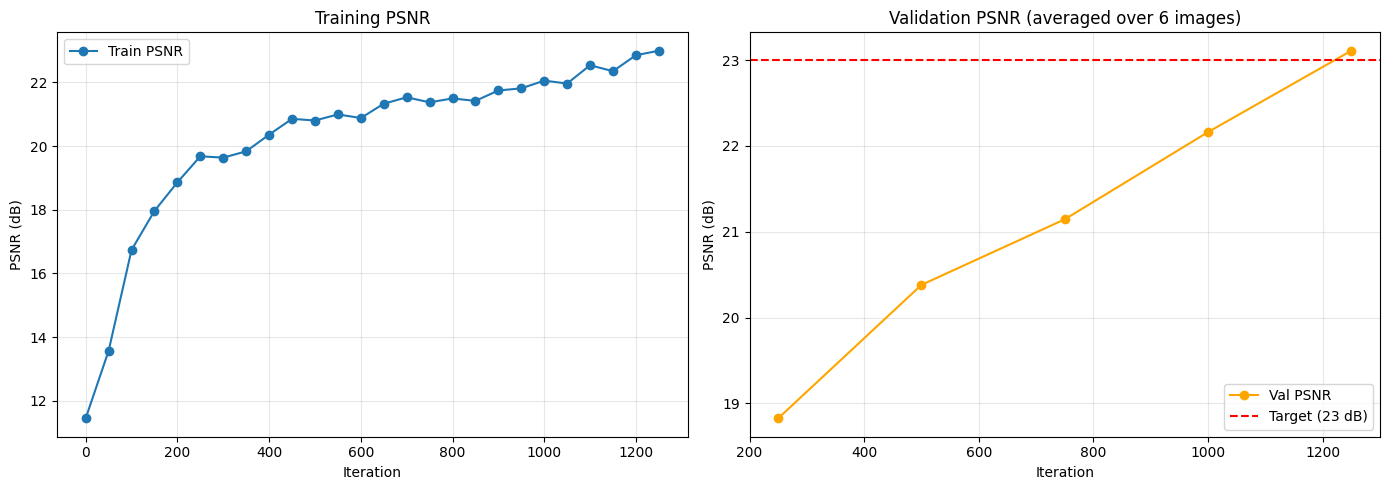


Final Validation PSNR: 23.11 dB


In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# training PSNR
if train_psnrs:
    train_iters, train_vals = zip(*train_psnrs)
    ax1.plot(train_iters, train_vals, marker='o', label='Train PSNR')
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('PSNR (dB)')
    ax1.set_title('Training PSNR')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

# validation PSNR
if val_psnrs_history:
    val_iters, val_vals = zip(*val_psnrs_history)
    ax2.plot(val_iters, val_vals, marker='o', color='orange', label='Val PSNR')
    ax2.axhline(y=23, color='r', linestyle='--', label='Target (23 dB)')
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('PSNR (dB)')
    ax2.set_title('Validation PSNR (averaged over 6 images)')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

plt.tight_layout()
plt.savefig('lego_progression_more_iters/lego_psnr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFinal Validation PSNR: {val_psnrs_history[-1][1]:.2f} dB")

In [30]:
# spherical rendering of lego video, novel from arbitrary camera extrinsic
data = np.load("lego_200x200.npz")
c2ws_test = torch.from_numpy(data["c2ws_test"]).float().to(device) # provided camera extrinsics

model.eval()
frames = []

with torch.no_grad():
    for i in range(len(c2ws_test)):
        img = render_full_image(model, c2ws_test[i], K_t, H, W, n_samples, near, far, chunk_size=16384)

        img_np = (img.cpu().numpy() * 255).clip(0,255).astype(np.uint8)
        frames.append(img_np)

        Image.fromarray(img_np).save(f"lego-vid-frames/frame_{i:03d}.png")
        print(f"Rendered view {i+1}/{len(c2ws_test)}")


gif_path = "lego_360.gif" # name for output gif
imageio.mimsave(gif_path, frames, fps=20)
print(f"Saved GIF to {gif_path}")

Rendered view 1/60
Rendered view 2/60
Rendered view 3/60
Rendered view 4/60
Rendered view 5/60
Rendered view 6/60
Rendered view 7/60
Rendered view 8/60
Rendered view 9/60
Rendered view 10/60
Rendered view 11/60
Rendered view 12/60
Rendered view 13/60
Rendered view 14/60
Rendered view 15/60
Rendered view 16/60
Rendered view 17/60
Rendered view 18/60
Rendered view 19/60
Rendered view 20/60
Rendered view 21/60
Rendered view 22/60
Rendered view 23/60
Rendered view 24/60
Rendered view 25/60
Rendered view 26/60
Rendered view 27/60
Rendered view 28/60
Rendered view 29/60
Rendered view 30/60
Rendered view 31/60
Rendered view 32/60
Rendered view 33/60
Rendered view 34/60
Rendered view 35/60
Rendered view 36/60
Rendered view 37/60
Rendered view 38/60
Rendered view 39/60
Rendered view 40/60
Rendered view 41/60
Rendered view 42/60
Rendered view 43/60
Rendered view 44/60
Rendered view 45/60
Rendered view 46/60
Rendered view 47/60
Rendered view 48/60
Rendered view 49/60
Rendered view 50/60
Rendered 

### Part 2.6: Training with your own data

In [89]:
# my_data.npz training

# laod data
# data = np.load("my_data.npz")
data = np.load("octo_data.npz")
images_train = data["images_train"]
c2ws_train = data["c2ws_train"]
images_val = data["images_val"]
c2ws_val = data["c2ws_val"]
focal_len = data["focal"]
H, W = images_train.shape[1:3]

# create the K matrix
K_matrix = np.array([
    [focal_len, 0, W/2],
    [0, focal_len, H/2],
    [0, 0, 1]
], dtype=np.float32)


# convert to Tensors
images_train_t = torch.from_numpy(images_train / 255.0).float().to(device)
c2ws_train_t = torch.from_numpy(c2ws_train).float().to(device)
images_val_t = torch.from_numpy(images_val / 255.0).float().to(device)
c2ws_val_t = torch.from_numpy(c2ws_val).float().to(device)
K_t = torch.from_numpy(K_matrix).float().to(device)

# hyperparameters
num_iters = 1500 # number of gradient steps, staff solution only took 1000
batch_size = 4096 # staff used 10k rays per step
lr = 5e-4 # try smaller learning rate compared to staff's 5e-4
n_samples = 64
near = 0.07 # 0.5, 0.1
far = 0.9 # 2.5, 0.8
# log_every = 100 # save an image every log_every iterations
psnr_target = 23 # for deliverables section we want to reach at least 23 PSNR


# initialize dataset, model, optimizer, loss function
dataset = RaysData(images_train_t, c2ws_train_t, K_t)
model = NeRF(L_pos = 7, L_dir = 4).to(device) # L_pos originally at 10, lowered to 6 to try and improve val psnr
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
mse_loss_fn = nn.MSELoss()

# # trying learning rate decay exponentially
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
#     optimizer, T_max=num_iters, eta_min=1e-5
# )


# adding time checks
print("Starting training...")
train_psnrs = []
val_psnrs_history = []
start_time = time.time() # start timer

for i in range(num_iters + 1):
    model.train() # set model to training mode
    
    # 1. Sample and train
    r_o, r_d, gt_colors = dataset.sample_rays(batch_size)
    points_3d, t_vals = sample_along_rays(r_o, r_d, n_samples, near, far, perturb=True)
    pred_rgb, pred_sigma = model(points_3d, r_d)
    step_size = (far - near) / n_samples
    rendered_colors = volrend(pred_sigma, pred_rgb, step_size) # make sure volrend() parameters (density, color) are in the right order
    
    # 2. Loss and Backprop
    loss = mse_loss_fn(rendered_colors, gt_colors)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # scheduler.step() # update learning rate


    # # === DIAGNOSTIC TEST ===
    # print("Running diagnostic test...")
    # test_start = time.time()

    # # Single training iteration
    # r_o, r_d, gt_colors = dataset.sample_rays(batch_size)
    # print(f"  1. Ray sampling: {time.time() - test_start:.2f}s")

    # t1 = time.time()
    # points_3d, t_vals = sample_along_rays(r_o, r_d, n_samples, near, far, perturb=True)
    # print(f"  2. Sample along rays: {time.time() - t1:.2f}s")

    # t2 = time.time()
    # pred_rgb, pred_sigma = model(points_3d, r_d)
    # print(f"  3. Model forward: {time.time() - t2:.2f}s")

    # t3 = time.time()
    # step_size = (far - near) / n_samples
    # rendered_colors = volrend(pred_sigma, pred_rgb, step_size)
    # print(f"  4. Volume render: {time.time() - t3:.2f}s")

    # t4 = time.time()
    # loss = mse_loss_fn(rendered_colors, gt_colors)
    # optimizer.zero_grad()
    # loss.backward()
    # optimizer.step()
    # print(f"  5. Backprop: {time.time() - t4:.2f}s")

    # print(f"Total iteration time: {time.time() - test_start:.2f}s\n")
    # # === END DIAGNOSTIC ===


    

    # 3. logging and deliverables
    if i % 50 == 0 or i == num_iters:
        # Log training PSNR
        train_psnr = 10.0 * torch.log10(1.0 / loss).item()
        train_psnrs.append((i, train_psnr))
        
        elapsed = time.time() - start_time
        print(f"Iter {i}/{num_iters} ({elapsed:.1f}s): Train Loss={loss.item():.5f}, Train PSNR={train_psnr:.2f} dB")

        # current_lr = scheduler.get_last_lr()[0]
        # print(f"-> Iter {i}: LR={current_lr:.6f}")

    # optimized validation
    # validation less frequently and only on one image for speed
    if (i > 0) and (i % 250 == 0 or i == num_iters):
        model.eval()
        val_start = time.time()
        
        with torch.no_grad():
            # ONLY render first validation image
            val_img_tensor = render_full_image(
                model, c2ws_val_t[0], K_t, H, W, n_samples, near, far, chunk_size=16384
            )
            
            # calculate PSNR for just this one image
            val_mse = F.mse_loss(val_img_tensor, images_val_t[0])
            val_psnr = 10.0 * torch.log10(1.0 / val_mse).item()
            val_psnrs_history.append((i, val_psnr))
            print(f"  -> Validating (1 image) took {time.time() - val_start:.2f}s")
            print(f"  -> Val PSNR (image 0): {val_psnr:.2f} dB")

            # save this image (no redundant rendering)
            img_np = (val_img_tensor.cpu().numpy() * 255).clip(0, 255).astype(np.uint8)
            img_path = os.path.join("octo2-progression", f"iter_{i:05d}.png")
            Image.fromarray(img_np).save(img_path)
            print(f"  -> Saved progression image to {img_path}")
            
            # check if we've met target and can end early
            if val_psnr >= psnr_target:
                print(f"Met target PSNR of {psnr_target} dB! Stopping training.")
                break
        
        model.train() # set back to train mode for next iteration

print(f"Training complete in {time.time() - start_time:.1f}s.")

RaysData: 50 images, 640x480 resolution.
Starting training...
Iter 0/1500 (3.0s): Train Loss=0.34480, Train PSNR=4.62 dB
Iter 50/1500 (89.3s): Train Loss=0.05970, Train PSNR=12.24 dB
Iter 100/1500 (170.5s): Train Loss=0.05720, Train PSNR=12.43 dB
Iter 150/1500 (250.1s): Train Loss=0.04949, Train PSNR=13.05 dB
Iter 200/1500 (363.2s): Train Loss=0.03610, Train PSNR=14.42 dB
Iter 250/1500 (455.7s): Train Loss=0.03234, Train PSNR=14.90 dB
  -> Validating (1 image) took 424.04s
  -> Val PSNR (image 0): 11.85 dB
  -> Saved progression image to octo2-progression/iter_00250.png
Iter 300/1500 (996.6s): Train Loss=0.02807, Train PSNR=15.52 dB
Iter 350/1500 (1085.4s): Train Loss=0.02882, Train PSNR=15.40 dB
Iter 400/1500 (1168.6s): Train Loss=0.02587, Train PSNR=15.87 dB
Iter 450/1500 (1253.9s): Train Loss=0.02574, Train PSNR=15.89 dB
Iter 500/1500 (1346.7s): Train Loss=0.02418, Train PSNR=16.17 dB
  -> Validating (1 image) took 658.10s
  -> Val PSNR (image 0): 12.42 dB
  -> Saved progression ima

KeyboardInterrupt: 

In [ ]:
# load data
data = np.load("octo_data.npz")
images_train = data["images_train"]
c2ws_train = data["c2ws_train"]
focal = data["focal"]

print(f"Training images: {images_train.shape}")
print(f"Image resolution: {images_train.shape[1]}x{images_train.shape[2]}")
print(f"Focal length: {focal:.2f}")

# check camera distances
distances = [np.linalg.norm(c2w[:3, 3]) for c2w in c2ws_train]
print(f"\nCamera distances from origin:")
print(f"  Min: {np.min(distances):.3f}m")
print(f"  Max: {np.max(distances):.3f}m")
print(f"  Mean: {np.mean(distances):.3f}m")

# recommended near/far
print(f"\nRECOMMENDED SETTINGS:")
print(f"  near = {np.min(distances) * 0.3:.3f}")
print(f"  far = {np.max(distances) * 1.5:.3f}")

# check image brightness (make sure images aren't too dark/bright)
mean_brightness = np.mean(images_train)
print(f"\nMean image brightness: {mean_brightness:.1f} (should be 100-150)")

Training images: (50, 640, 480, 3)
Image resolution: 640x480
Focal length: 494.10

Camera distances from origin:
  Min: 0.298m
  Max: 0.502m
  Mean: 0.395m

RECOMMENDED SETTINGS:
  near = 0.089
  far = 0.754

Mean image brightness: 137.1 (should be 100-150)


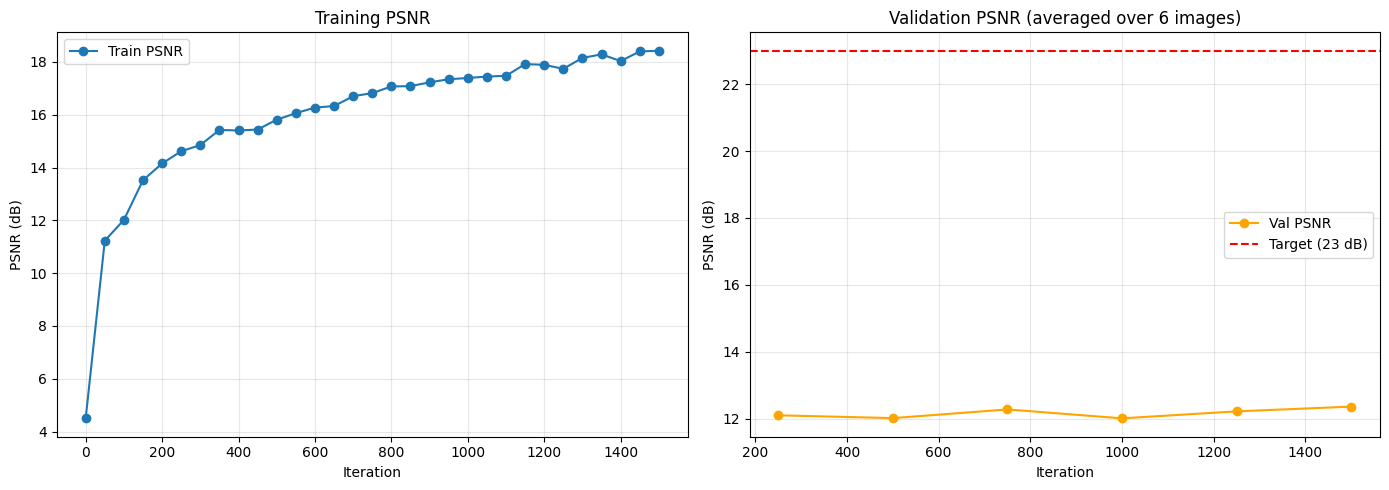


Final Validation PSNR: 12.36 dB


In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# training PSNR
if train_psnrs:
    train_iters, train_vals = zip(*train_psnrs)
    ax1.plot(train_iters, train_vals, marker='o', label='Train PSNR')
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('PSNR (dB)')
    ax1.set_title('Training PSNR')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

# validation PSNR
if val_psnrs_history:
    val_iters, val_vals = zip(*val_psnrs_history)
    ax2.plot(val_iters, val_vals, marker='o', color='orange', label='Val PSNR')
    ax2.axhline(y=23, color='r', linestyle='--', label='Target (23 dB)')
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('PSNR (dB)')
    ax2.set_title('Validation PSNR (averaged over 6 images)')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

plt.tight_layout()
plt.savefig('octo-progression/octo_psnr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFinal Validation PSNR: {val_psnrs_history[-1][1]:.2f} dB")